# Setup Experiment

This notebook blends **Stata** and **Python** in a single workflow:

| Cell type | What it does |
|---|---|
| `%%stata` magic | Runs Stata commands via `pystata` (ships with Stata 17+) |
| Regular Python | Uses `pandas` and `matplotlib` for further analysis |


In [14]:
#%autoreload 2 reloads your src/c08_farming_exit modules automatically whenever you save a .py file
%load_ext autoreload
%autoreload 2

from c08_farming_exit.visuals import plot_price_distribution
from c08_farming_exit.stata_utils import init_stata

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Initialise pystata

In [15]:
init_stata()
from pystata import stata

## 2. Run Do File

In [16]:
%%stata
do "../stata/99_dofile_experiment.do"


. * ===========================================================================
> ==
. * clean_data.do
. * Loads Stata's built-in auto dataset, performs basic cleaning, and saves
. * a cleaned copy to data/auto_clean.dta for use in the EDA notebook.
. * ===========================================================================
> ==
. 
. * ── 0. Working directory ───────────────────────────────────────────────────
> ──
. * Stata sets the working directory to the folder containing this do-file
. * when you run it with the VSCode extension (Run button / Ctrl+Shift+D).
. * If that is not the case, uncomment and adjust the line below:
. * cd "C:\Users\localuser\my_projects\demo_app"
. 
. * ── 1. Load raw data ───────────────────────────────────────────────────────
> ───
. sysuse auto, clear          // ships with every Stata installation
(1978 automobile data)

. 
. * ── 2. Inspect ─────────────────────────────────────────────────────────────
> ──
. describe

Contains data from C:\Program

## 2. Quick Stata summary (Stata cell)

In [17]:
%%stata
use "../data/processed/01_experiment_data.dta", clear
describe
summarize price mpg weight repair_record price_per_mpg
tabulate foreign


. use "../data/processed/01_experiment_data.dta", clear
(1978 automobile data)

. describe

Contains data from ../data/processed/01_experiment_data.dta
 Observations:            69                  1978 automobile data
    Variables:            13                  15 Jul 2026 15:08
                                              (_dta has notes)
-------------------------------------------------------------------------------
Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
make            str18   %-18s                 Make and model
price           int     %8.0gc                Price
mpg             int     %8.0g                 Mileage (mpg)
repair_record   int     %8.0g                 Repair record 1978
headroom        float   %6.1f                 Headroom (in.)
trunk           int     %8.0g                 Trunk space (cu. ft.)
weight          int     

## 3. Load cleaned data into pandas

In [19]:
df = pd.read_stata("../data/processed/01_experiment_data.dta")

print(f"Rows: {len(df)}  |  Columns: {df.shape[1]}")
df.head()

Rows: 69  |  Columns: 13


,make,price,mpg,repair_record,headroom,trunk,weight,length,turn,displacement,gear_ratio,foreign,price_per_mpg
0,AMC Concord,4099,22,3,2.5,11,2930,186,40,121,3.58,Domestic,186.318176
1,AMC Pacer,4749,17,3,3.0,11,3350,173,40,258,2.53,Domestic,279.352936
2,Buick Century,4816,20,3,4.5,16,3250,196,40,196,2.93,Domestic,240.800003
3,Buick Electra,7827,15,4,4.0,20,4080,222,43,350,2.41,Domestic,521.799988
4,Buick LeSabre,5788,18,3,4.0,21,3670,218,43,231,2.73,Domestic,321.555542


## 4. Price distribution

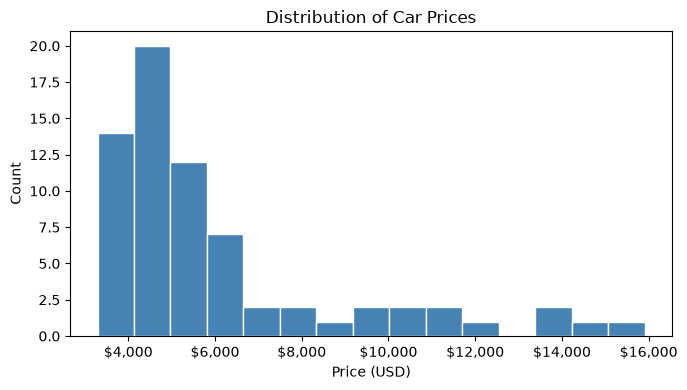

(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Car Prices'}, xlabel='Price (USD)', ylabel='Count'>)

In [20]:

plot_price_distribution(df)

## 5. Quick Stata regression

Round-trip: pass the pandas DataFrame back into Stata, run a regression, display results.

In [21]:
stata.pdataframe_to_data(df, force=True)

In [22]:
#If you'd rather save to a .dta file first and then load it in Stata, you can do that too:
df.to_stata('../data/processed/02_experiment_data.dta', write_index=False)

In [23]:
%%stata
use "../data/processed/02_experiment_data.dta", clear
regress price mpg weight i.repair_record i.foreign
estat summarize


. use "../data/processed/02_experiment_data.dta", clear

. regress price mpg weight i.repair_record i.foreign

      Source |       SS           df       MS      Number of obs   =        69
-------------+----------------------------------   F(7, 61)        =      8.78
       Model |   289409242         7  41344177.4   Prob > F        =    0.0000
    Residual |   287387717        61  4711274.05   R-squared       =    0.5018
-------------+----------------------------------   Adj R-squared   =    0.4446
       Total |   576796959        68  8482308.22   Root MSE        =    2170.5

------------------------------------------------------------------------------
       price | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         mpg |   24.37505   81.24383     0.30   0.765     -138.082    186.8321
      weight |   3.545366   .6740969     5.26   0.000     2.197426    4.893306
             |
rep